__Global SHAP__

In [61]:
# setup and imports

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

shap.initjs()  # For visual force plots

__Base model: ALL Features (Decision Tree)__

In [62]:
df = pd.read_csv("b_all.csv")
target = df["AgreeSubsequentBooster"]
features = df.drop("AgreeSubsequentBooster", axis=1)
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=0)

In [63]:
from sklearn.tree import DecisionTreeClassifier

# run the decision tree model

model_dt = DecisionTreeClassifier(max_depth=5, criterion='entropy', random_state=42)
model_dt.fit(x_train, y_train)

print("Decision Tree Train Accuracy:", model_dt.score(x_train, y_train))
print("Decision Tree Test Accuracy:", model_dt.score(x_test, y_test))

Decision Tree Train Accuracy: 0.89937106918239
Decision Tree Test Accuracy: 0.825


In [64]:
# Background as DataFrame (representative subset of training data)
background = shap.sample(x_train, 50, random_state=0)

# Function returning probability of positive class
def model_predict_proba(X):
    X = pd.DataFrame(X, columns=x_train.columns)
    return model_dt.predict_proba(X)

# Kernel SHAP explainer
explainer = shap.KernelExplainer(model_predict_proba, background)

# Compute SHAP values on test set
shap_values = explainer.shap_values(x_test)

# Positive class (class = 1)
shap_values_pos = shap_values[:, :, 1]
expected_value = explainer.expected_value[1]

  0%|          | 0/40 [00:00<?, ?it/s]

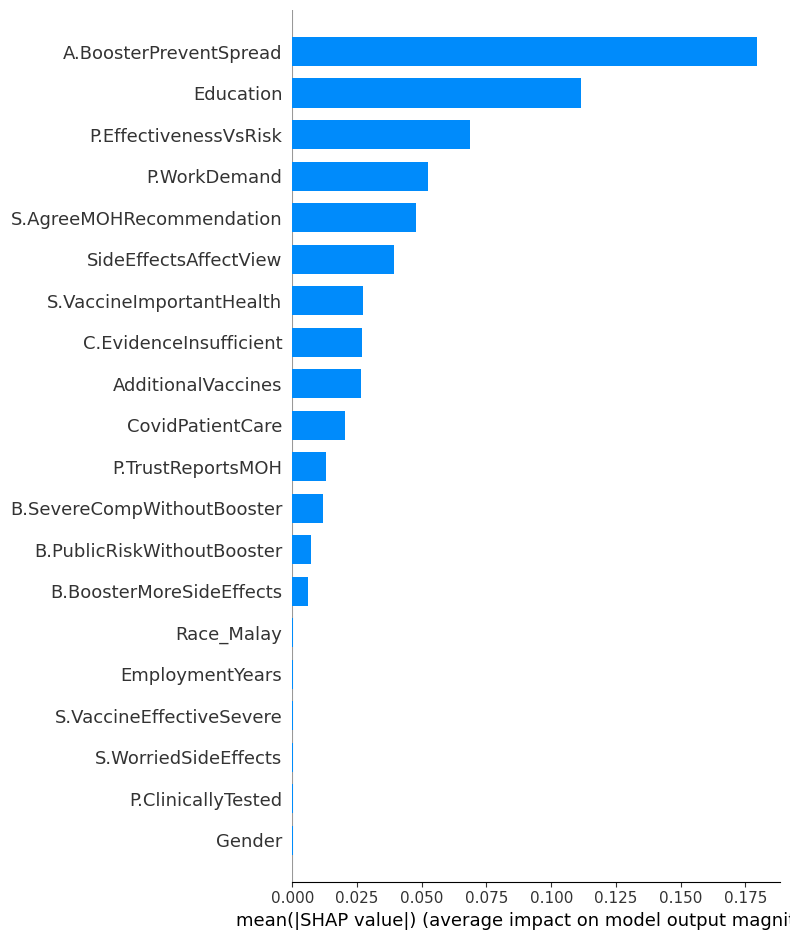

In [65]:
shap.summary_plot(
    shap_values_pos,
    x_test,
    plot_type="bar",
    show=True
)

In [66]:
# print out all shap values

mean_shap = np.abs(shap_values_pos).mean(axis=0)

shap_df = pd.DataFrame({
    "Feature": x_test.columns,
    "SHAP_Score": mean_shap
})

shap_df = shap_df.sort_values(by="SHAP_Score", ascending=False)

print(shap_df)

shap_df.to_csv("test_a.csv", index=False)

                     Feature  SHAP_Score
41    A.BoosterPreventSpread    0.179383
2                  Education    0.111368
29     P.EffectivenessVsRisk    0.068517
38              P.WorkDemand    0.052296
24  S.AgreeMOHRecommendation    0.047846
..                       ...         ...
42   A.ReturnDailyActivities    0.000000
43     A.RecommendingBooster    0.000000
44        A.MaintainAntibody    0.000000
45    A.NoSeriousSideEffects    0.000000
79       Location_Terengganu    0.000000

[80 rows x 2 columns]


__Base model - ALL Features (SVM rbf)__

SVM RBF Train Accuracy: 0.9811320754716981
SVM RBF Test Accuracy: 0.825


  0%|          | 0/40 [00:00<?, ?it/s]

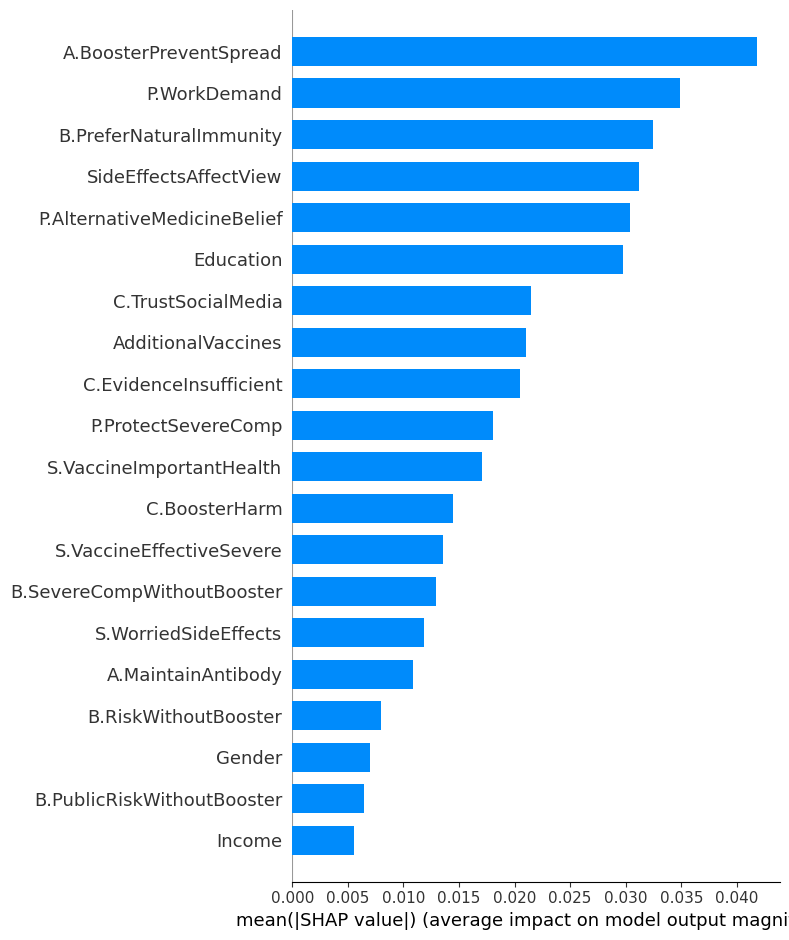

In [67]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import shap

df = pd.read_csv("b_all.csv")
target = df["AgreeSubsequentBooster"]
features = df.drop("AgreeSubsequentBooster", axis=1)

x_train, x_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=0
)

# run the SVM RBF model
model_svm_rbf = SVC(C=10, kernel='rbf', gamma='scale', probability=True, random_state=42)
model_svm_rbf.fit(x_train, y_train)

print("SVM RBF Train Accuracy:", model_svm_rbf.score(x_train, y_train))
print("SVM RBF Test Accuracy:", model_svm_rbf.score(x_test, y_test))

# Background as DataFrame (representative subset of training data)
background = shap.sample(x_train, 50, random_state=0)


# Function returning probability of positive class
def model_predict_proba(X):
    X = pd.DataFrame(X, columns=x_train.columns)
    return model_svm_rbf.predict_proba(X)


# Kernel SHAP explainer
explainer = shap.KernelExplainer(model_predict_proba, background)

# Compute SHAP values on test set
shap_values = explainer.shap_values(x_test)

# Positive class (class = 1)
shap_values_pos = shap_values[:, :, 1]
expected_value = explainer.expected_value[1]

shap.summary_plot(
    shap_values_pos,
    x_test,
    plot_type="bar",
    show=True
)

In [68]:
# print out all shap values

mean_shap = np.abs(shap_values_pos).mean(axis=0)

shap_df = pd.DataFrame({
    "Feature": x_test.columns,
    "SHAP_Score": mean_shap
})

In [69]:
shap_df = shap_df.sort_values(by="SHAP_Score", ascending=False)

print(shap_df)

shap_df.to_csv("test_b.csv", index=False)

                             Feature  SHAP_Score
41            A.BoosterPreventSpread    0.041789
38                      P.WorkDemand    0.034897
53           B.PreferNaturalImmunity    0.032460
16             SideEffectsAffectView    0.031193
36       P.AlternativeMedicineBelief    0.030345
..                               ...         ...
43             A.RecommendingBooster    0.000000
45            A.NoSeriousSideEffects    0.000000
49  B.TransmitPatientsWithoutBooster    0.000000
50                B.SkepticalBooster    0.000000
79               Location_Terengganu    0.000000

[80 rows x 2 columns]


__ALL Features with Anova + Chi Square (GNB)__

GNB Train Accuracy: 0.7044025157232704
GNB Test Accuracy: 0.9


  0%|          | 0/40 [00:00<?, ?it/s]

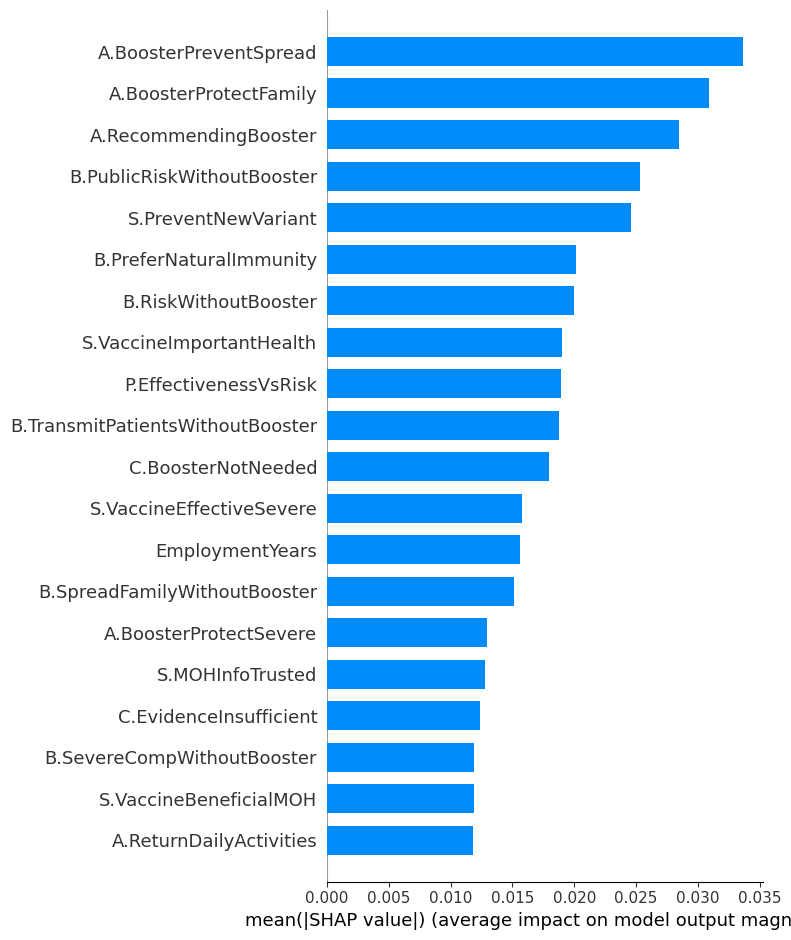

In [49]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
import shap

df = pd.read_csv("b_all_ac.csv")
target = df["AgreeSubsequentBooster"]
features = df.drop("AgreeSubsequentBooster", axis=1)

x_train, x_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=0
)

# run the GNB model
model_gnb = GaussianNB()
model_gnb.fit(x_train, y_train)

print("GNB Train Accuracy:", model_gnb.score(x_train, y_train))
print("GNB Test Accuracy:", model_gnb.score(x_test, y_test))

# Background as DataFrame (representative subset of training data)
background = shap.sample(x_train, 50, random_state=0)


# Function returning probability of positive class
def model_predict_proba(X):
    X = pd.DataFrame(X, columns=x_train.columns)
    return model_gnb.predict_proba(X)


# Kernel SHAP explainer
explainer = shap.KernelExplainer(model_predict_proba, background)

# Compute SHAP values on test set
shap_values = explainer.shap_values(x_test)

# Positive class (class = 1)
shap_values_pos = shap_values[:, :, 1]
expected_value = explainer.expected_value[1]

shap.summary_plot(
    shap_values_pos,
    x_test,
    plot_type="bar",
    show=True
)

In [50]:
# print out all shap values

mean_shap = np.abs(shap_values_pos).mean(axis=0)

shap_df = pd.DataFrame({
    "Feature": x_test.columns,
    "SHAP_Score": mean_shap
})

In [51]:
shap_df = shap_df.sort_values(by="SHAP_Score", ascending=False)

print(shap_df)

                             Feature  SHAP_Score
20            A.BoosterPreventSpread    0.033616
19            A.BoosterProtectFamily    0.030885
22             A.RecommendingBooster    0.028490
33        B.PublicRiskWithoutBooster    0.025283
10               S.PreventNewVariant    0.024556
31           B.PreferNaturalImmunity    0.020123
25              B.RiskWithoutBooster    0.019997
2           S.VaccineImportantHealth    0.018974
12             P.EffectivenessVsRisk    0.018891
28  B.TransmitPatientsWithoutBooster    0.018724
34                C.BoosterNotNeeded    0.017942
3           S.VaccineEffectiveSevere    0.015766
1                    EmploymentYears    0.015601
27      B.SpreadFamilyWithoutBooster    0.015146
18            A.BoosterProtectSevere    0.012965
7                   S.MOHInfoTrusted    0.012776
36            C.EvidenceInsufficient    0.012356
26        B.SevereCompWithoutBooster    0.011924
5             S.VaccineBeneficialMOH    0.011859
21           A.Retur

__Booster avg all features: Bagging (SVM poly)__

Bagging (SVM poly) Train Accuracy: 0.8050314465408805
Bagging (SVM poly) Test Accuracy: 0.65


  0%|          | 0/40 [00:00<?, ?it/s]

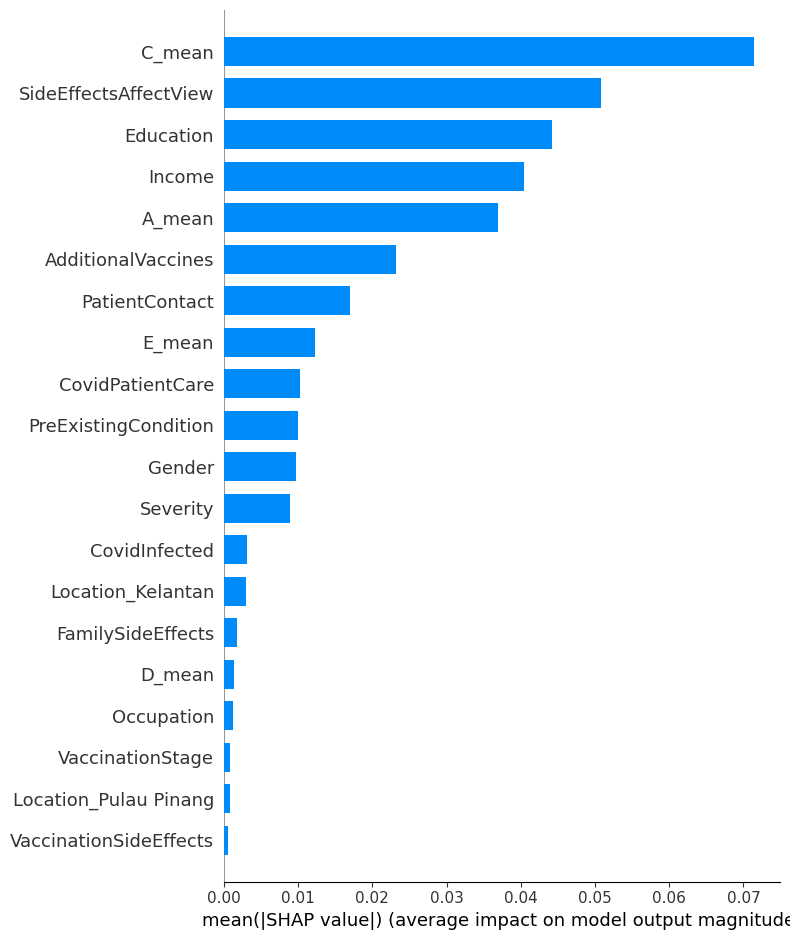

In [52]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
import shap

df = pd.read_csv("b_avg_all.csv")
target = df["AgreeSubsequentBooster"]
features = df.drop("AgreeSubsequentBooster", axis=1)

x_train, x_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

# base model: SVM poly
base_svm_poly = SVC(
    C=1,
    kernel='poly',
    degree=2,
    gamma='scale',
    probability=True,
    random_state=42
)

# bagging model
model_bagging_svm_poly = BaggingClassifier(
    estimator=base_svm_poly,
    n_estimators=10,
    random_state=42
)

model_bagging_svm_poly.fit(x_train, y_train)

print("Bagging (SVM poly) Train Accuracy:", model_bagging_svm_poly.score(x_train, y_train))
print("Bagging (SVM poly) Test Accuracy:", model_bagging_svm_poly.score(x_test, y_test))

# Background as DataFrame (representative subset of training data)
background = shap.sample(x_train, 50, random_state=42)


# Function returning probability of positive class
def model_predict_proba(X):
    X = pd.DataFrame(X, columns=x_train.columns)
    return model_bagging_svm_poly.predict_proba(X)


# Kernel SHAP explainer
explainer = shap.KernelExplainer(model_predict_proba, background)

# Compute SHAP values on test set
shap_values = explainer.shap_values(x_test)

# Positive class (class = 1)
shap_values_pos = shap_values[:, :, 1]
expected_value = explainer.expected_value[1]

shap.summary_plot(
    shap_values_pos,
    x_test,
    plot_type="bar",
    show=True
)

In [53]:
# print out all shap values

mean_shap = np.abs(shap_values_pos).mean(axis=0)

shap_df = pd.DataFrame({
    "Feature": x_test.columns,
    "SHAP_Score": mean_shap
})

In [54]:
shap_df = shap_df.sort_values(by="SHAP_Score", ascending=False)

print(shap_df)

                     Feature  SHAP_Score
38                    C_mean    0.071365
16     SideEffectsAffectView    0.050798
2                  Education    0.044207
3                     Income    0.040388
36                    A_mean    0.036908
12        AdditionalVaccines    0.023151
5             PatientContact    0.016942
40                    E_mean    0.012259
7           CovidPatientCare    0.010222
9       PreExistingCondition    0.009963
1                     Gender    0.009718
11                  Severity    0.008978
10             CovidInfected    0.003168
26         Location_Kelantan    0.002928
15         FamilySideEffects    0.001727
39                    D_mean    0.001390
6                 Occupation    0.001223
13          VaccinationStage    0.000828
32     Location_Pulau Pinang    0.000793
14    VaccinationSideEffects    0.000557
0                        Age    0.000249
22            Religion_Hindu    0.000236
25            Location_Kedah    0.000207
37              

__Booster avg - anova + chi: Boosting__

Boosting Train Accuracy: 0.9937106918238994
Boosting Test Accuracy: 0.825


  0%|          | 0/40 [00:00<?, ?it/s]

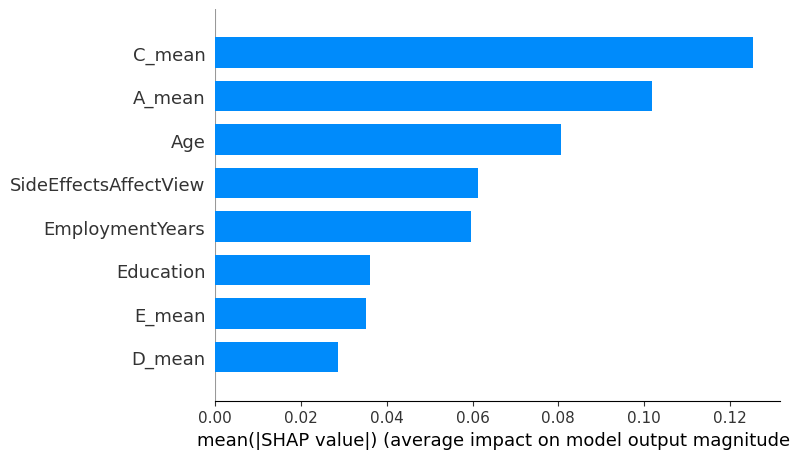

In [55]:
df = pd.read_csv("b_avg_ac.csv")
target = df["AgreeSubsequentBooster"]
features = df.drop("AgreeSubsequentBooster", axis=1)
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

from sklearn.ensemble import GradientBoostingClassifier

model_boosting = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

model_boosting.fit(x_train, y_train)

print("Boosting Train Accuracy:", model_boosting.score(x_train, y_train))
print("Boosting Test Accuracy:", model_boosting.score(x_test, y_test))
# Background as DataFrame (representative subset of training data)
background = shap.sample(x_train, 50, random_state=42)


# Function returning probability of positive class
def model_predict_proba(X):
    X = pd.DataFrame(X, columns=x_train.columns)
    return model_boosting.predict_proba(X)


# Kernel SHAP explainer
explainer = shap.KernelExplainer(model_predict_proba, background)

# Compute SHAP values on test set
shap_values = explainer.shap_values(x_test)

# Positive class (class = 1)
shap_values_pos = shap_values[:, :, 1]
expected_value = explainer.expected_value[1]
shap.summary_plot(
    shap_values_pos,
    x_test,
    plot_type="bar",
    show=True
)

In [56]:
# print out all shap values

mean_shap = np.abs(shap_values_pos).mean(axis=0)

shap_df = pd.DataFrame({
    "Feature": x_test.columns,
    "SHAP_Score": mean_shap
})

In [57]:
shap_df = shap_df.sort_values(by="SHAP_Score", ascending=False)

print(shap_df)

                 Feature  SHAP_Score
3                 C_mean    0.125393
2                 A_mean    0.101906
0                    Age    0.080590
7  SideEffectsAffectView    0.061215
1        EmploymentYears    0.059722
6              Education    0.036012
5                 E_mean    0.035148
4                 D_mean    0.028578


__Aggregated Features with Anova + Chi Square - GNB__

GNB Train Accuracy: 0.7672955974842768
GNB Test Accuracy: 0.65


  0%|          | 0/40 [00:00<?, ?it/s]

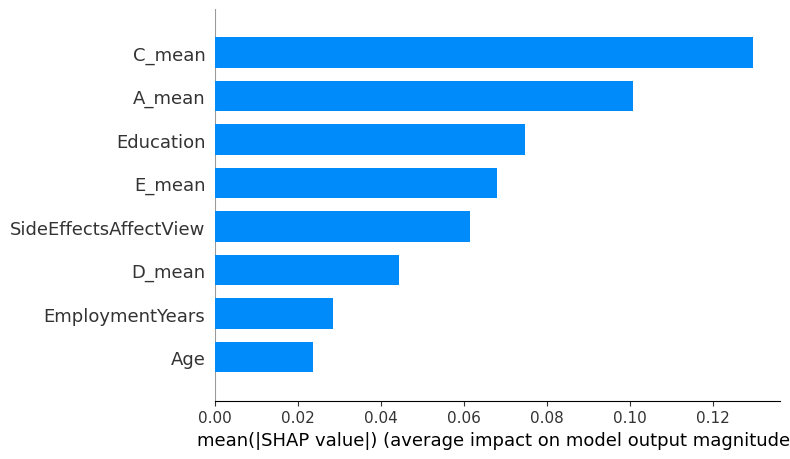

In [58]:
df = pd.read_csv("b_avg_ac.csv")
target = df["AgreeSubsequentBooster"]
features = df.drop("AgreeSubsequentBooster", axis=1)

x_train, x_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

from sklearn.naive_bayes import GaussianNB

# run the GNB model
model_gnb = GaussianNB()
model_gnb.fit(x_train, y_train)

print("GNB Train Accuracy:", model_gnb.score(x_train, y_train))
print("GNB Test Accuracy:", model_gnb.score(x_test, y_test))

# Background as DataFrame (representative subset of training data)
background = shap.sample(x_train, 50, random_state=42)

# Function returning probability of positive class
def model_predict_proba(X):
    X = pd.DataFrame(X, columns=x_train.columns)
    return model_gnb.predict_proba(X)

# Kernel SHAP explainer
explainer = shap.KernelExplainer(model_predict_proba, background)

# Compute SHAP values on test set
shap_values = explainer.shap_values(x_test)

# Positive class (class = 1)
shap_values_pos = shap_values[:, :, 1]
expected_value = explainer.expected_value[1]

shap.summary_plot(
    shap_values_pos,
    x_test,
    plot_type="bar",
    show=True
)

In [59]:
# print out all shap values

mean_shap = np.abs(shap_values_pos).mean(axis=0)

shap_df = pd.DataFrame({
    "Feature": x_test.columns,
    "SHAP_Score": mean_shap
})

In [60]:
shap_df = shap_df.sort_values(by="SHAP_Score", ascending=False)

print(shap_df)

                 Feature  SHAP_Score
3                 C_mean    0.129686
2                 A_mean    0.100842
6              Education    0.074686
5                 E_mean    0.067890
7  SideEffectsAffectView    0.061497
4                 D_mean    0.044290
1        EmploymentYears    0.028510
0                    Age    0.023577
